# 📊 Notebook 04 — Análise Econômica Comparativa: Migração ao Mercado Livre (Grupo B3)

**Mestrado Profissional em Engenharia Elétrica — IFSC**
**Disciplina:** Técnicas de IA Aplicadas a Sistemas de Energia
**Autor:** Dilsonei José Rigotti

---

## Objetivo

Comparar o custo total projetado do **Mercado Cativo (CELESC Grupo B3)** com o **Mercado Livre
(CCEE/PLD + TUSD + encargos)** para abr/2026–dez/2030, combinando a previsão de consumo do
Notebook 03 (LSTM) com a projeção de tarifas e PLD desta análise, conforme as Seções VII–XI do
relatório final.

## Estrutura
1. Tarifas ANEEL (CELESC B3) e PLD Sul (CCEE) — dados reais tratados pelo Notebook 0
2. Contexto histórico regulatório (2010–2025)
3. Gráficos comparativos históricos (Cativo x Livre, R$/kWh) e decomposição STL do PLD
4. Projeção de consumo (Notebook 03) e de tarifa/PLD até dez/2030
5. Simulação financeira Cativo x Livre em R$ totais (Seção VIII / Tabela III do relatório)
6. Aspectos contratuais da migração (prazo, preço, cláusulas de mercado)
7. Análise de sensibilidade e de risco hidrológico (Seções IX–XI do relatório)

> **Nota de versão:** a projeção de PLD via SARIMA e a projeção de tarifa via inflação setorial
> linear (8%/10%/6% a.a.) foram substituídas pela metodologia do relatório final: tarifa Cativa
> (TUSD+TE) mantida nos valores homologados até ago/2027 e projetada a 6% a.a. compostos depois
> disso; PLD Sul mantido nos valores observados até set/2026 e projetado pela média sazonal
> mensal do calendário (2021–2026). O horizonte de projeção passou de dez/2028 para dez/2030, e a
> simulação passou a multiplicar os custos unitários pelo consumo total projetado (Notebook 03),
> reproduzindo os valores agregados em R$ bilhões do relatório (Tabela III), em vez de comparar
> apenas o custo por kWh de um consumidor médio.

---
## 0. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings
from pathlib import Path

from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")

# Paths
BASE_DIR = Path("..").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROC = BASE_DIR / "data" / "processed"
PLOTS_DIR = BASE_DIR / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

# Estilo visual
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "cativo":   "#D62728",   # vermelho — mercado cativo (CELESC)
    "livre":    "#1F77B4",   # azul — mercado livre (CCEE)
    "saving":   "#2CA02C",   # verde — economia
    "projecao": "#FF7F0E",   # laranja — projeção
    "evento":   "#9467BD",   # roxo — eventos regulatórios
}

print("✅ Configurações carregadas.")

✅ Configurações carregadas.


---
## 1. Dados Reais ANEEL — Tarifas CELESC Grupo B3

### Fonte: Portal de Dados Abertos da ANEEL
URL: https://dadosabertos.aneel.gov.br/dataset/tarifas-distribuidoras-energia-eletrica
Arquivo tratado pelo Notebook 0: `tarifa_b3_celesc_mensal.csv`

**Estrutura:** Tarifas de Energia (TE) e TUSD homologadas pela ANEEL para a CELESC, Subgrupo B3,
modalidade Convencional, expandidas para série mensal contínua.

In [2]:
# Usa a série já tratada pelo Notebook 0 (filtro DscDetalhe=='Não se aplica',
# DscBaseTarifaria=='Tarifa de Aplicação'; vigências expandidas em série mensal contínua).
df_tarifa_mensal = pd.read_csv(DATA_PROC / "tarifa_b3_celesc_mensal.csv", parse_dates=["data"])
df_tarifa_mensal = df_tarifa_mensal.set_index("data").asfreq("MS")
df_tarifa_mensal["ano"] = df_tarifa_mensal.index.year

tarifa_anual = (
    df_tarifa_mensal.groupby("ano")
    .agg(tarifa_celesc_mwh=("tarifa_cativo_rs_mwh", "mean"),
         tusd_mwh=("tusd_b3_rs_mwh", "mean"))
    .reset_index()
)
tarifa_anual["tarifa_celesc_kwh"] = tarifa_anual["tarifa_celesc_mwh"] / 1000
tarifa_anual["tusd_kwh"] = tarifa_anual["tusd_mwh"] / 1000

print(f'Tarifa B3 CELESC (mensal): {df_tarifa_mensal.index.min():%Y-%m} a {df_tarifa_mensal.index.max():%Y-%m}')
tarifa_anual.tail()

Tarifa B3 CELESC (mensal): 2010-08 a 2027-08


,ano,tarifa_celesc_mwh,tusd_mwh,tarifa_celesc_kwh,tusd_kwh
13,2023,579.666667,307.123333,0.579667,0.307123
14,2024,601.276667,305.483333,0.601277,0.305483
15,2025,643.833333,335.030000,0.643833,0.335030
16,2026,717.036667,387.180000,0.717037,0.387180
17,2027,759.750000,414.040000,0.759750,0.414040


---
## 2. PLD Submercado Sul (CCEE) — Custo do Mercado Livre

### Série Histórica PLD Médio Mensal
Valores reais coletados do Portal de Dados Abertos da CCEE e tratados pelo Notebook 0
(`pld_sul_mensal.csv`).

**Custo total no Mercado Livre (Grupo B3):**

$$\text{Custo ML} = \text{PLD}_\text{Sul} + \text{TUSD}_\text{B3 (ANEEL, real)} + \text{Encargos setoriais/margem (residual)}$$

In [3]:
# PLD real (CCEE) + TUSD real (ANEEL) + encargos residual.
# Substitui o dicionário digitado à mão (pld_historico) e a estimativa de TUSD desatualizada de
# versões anteriores por dados reais tratados pelo Notebook 0.
df_pld_mensal_ccee = pd.read_csv(DATA_PROC / "pld_sul_mensal.csv", parse_dates=["data"])
df_pld_mensal_ccee = df_pld_mensal_ccee.set_index("data").asfreq("MS")
df_pld_mensal_ccee["ano"] = df_pld_mensal_ccee.index.year

df_pld = (
    df_pld_mensal_ccee.groupby("ano")["pld_sul_rs_mwh"].mean().reset_index()
    .rename(columns={"pld_sul_rs_mwh": "pld_sul_mwh"})
)
df_pld["pld_sul_kwh"] = df_pld["pld_sul_mwh"] / 1000
df_pld = df_pld.merge(tarifa_anual[["ano", "tusd_kwh"]], on="ano", how="left")

# Encargos setoriais + margem de comercializadora, residual à TUSD real (que já vem de tarifa_anual)
# -- valor mantido constante por falta de série histórica própria para esse componente.
ENCARGOS_MARGEM_KWH = 0.077

df_pld["encargos_kwh"] = df_pld["tusd_kwh"] + ENCARGOS_MARGEM_KWH
df_pld["custo_ml_kwh"] = df_pld["pld_sul_kwh"] + df_pld["encargos_kwh"]
df_pld["custo_ml_kwh_otimista"] = df_pld["pld_sul_kwh"] * 0.85 + df_pld["encargos_kwh"]
df_pld["custo_ml_kwh_pessimista"] = df_pld["pld_sul_kwh"] * 1.20 + df_pld["encargos_kwh"]

print("Série PLD real (CCEE) + TUSD real (ANEEL) + encargos/margem residual (R$/kWh):")
print(df_pld[["ano", "pld_sul_mwh", "pld_sul_kwh", "encargos_kwh", "custo_ml_kwh"]].to_string(index=False))

Série PLD real (CCEE) + TUSD real (ANEEL) + encargos/margem residual (R$/kWh):
 ano  pld_sul_mwh  pld_sul_kwh  encargos_kwh  custo_ml_kwh
2001    51.267571     0.051268           NaN           NaN
2002    13.455833     0.013456           NaN           NaN
2003    13.910292     0.013910           NaN           NaN
2004    18.983667     0.018984           NaN           NaN
2005    33.871542     0.033872           NaN           NaN
2006    69.514375     0.069514           NaN           NaN
2007    91.898750     0.091899           NaN           NaN
2008   136.835250     0.136835           NaN           NaN
2009    40.044750     0.040045           NaN           NaN
2010    70.334750     0.070335      0.247380      0.317715
2011    28.078208     0.028078      0.248553      0.276632
2012   170.594792     0.170595      0.242940      0.413535
2013   253.435167     0.253435      0.191144      0.444579
2014   653.600708     0.653601      0.199447      0.853047
2015   280.535125     0.280535      

---
## 3. Contexto Histórico Regulatório (2010–2025)

Este período é essencial para a interpretação correta das séries temporais de custo.

In [4]:
eventos_regulatorios = [
    {
        "ano": 2010,
        "evento": "Acordo setorial e expansão das renováveis",
        "impacto": "Neutro/positivo",
        "descricao": "Leilões de energia eólica e solar impulsionam diversificação da matriz. "
                     "PLD baixo por boas condições hidrológicas.",
    },
    {
        "ano": 2012,
        "evento": 'MP 579/2012 — "Tarifaço" invertido',
        "impacto": "Distorção estrutural",
        "descricao": "Medida Provisória renova concessões de geração e transmissão com redução "
                     "forçada de ~20% nas tarifas. CELESC recebe cota de energia hidrelétrica "
                     "insuficiente para cobrir demanda, acumulando dívida setorial.",
    },
    {
        "ano": 2013,
        "evento": "Lei 12.783/2013 — conversão da MP 579",
        "impacto": "Passivo regulatório crescente",
        "descricao": "Seca severa força acionamento intensivo de termelétricas (custo médio "
                     ">5x o custo hidrelétrico). Distribuidoras acumulam déficit. "
                     "PLD dispara para R$ 282/MWh.",
    },
    {
        "ano": 2014,
        "evento": "Crise hídrica crítica — reservatórios no mínimo histórico",
        "impacto": "Máxima exposição de custo no ML",
        "descricao": "PLD atinge o teto regulatório (R$ 822/MWh). Empresas no Mercado Livre "
                     "têm custo total >R$ 1.000/MWh. No mercado cativo, o passivo é represado.",
    },
    {
        "ano": 2015,
        "evento": "Bandeiras Tarifárias (jan/2015) + RTE CELESC (+24,8%)",
        "impacto": "Realinhamento tarifário no cativo",
        "descricao": "Sistema de bandeiras implementado pela ANEEL para repassar em tempo real "
                     "os custos de geração termelétrica. A CELESC passa por Revisão Tarifária "
                     "Extraordinária (RTE) para recompor desequilíbrio financeiro acumulado "
                     "desde 2012. Tarifa B3 sobe ~24,8% em agosto/2015.",
    },
    {
        "ano": 2021,
        "evento": "Segunda Crise Hídrica — PLD no teto histórico",
        "impacto": "Máxima desvantagem do Mercado Livre",
        "descricao": "PLD Sul alcança R$ 548/MWh em média anual (teto de R$ 583/MWh). "
                     "Empresas com contratos no ML arcam com custos muito superiores ao cativo. "
                     "Demonstra o risco hidrológico intrínseco ao modelo de preço spot.",
    },
    {
        "ano": 2025,
        "evento": "Lei 15.269/2025 — Abertura do ML para Grupo B",
        "impacto": "Marco regulatório histórico",
        "descricao": "Define cronograma de migração: B3 comercial/industrial em nov/2027, "
                     "B1 residencial e B2 rural em nov/2028.",
    },
]

df_eventos = pd.DataFrame(eventos_regulatorios)
print("Timeline regulatória construída:")
df_eventos[["ano", "evento", "impacto"]].to_string(index=False)

Timeline regulatória construída:


' ano                                                    evento                             impacto\n2010                 Acordo setorial e expansão das renováveis                     Neutro/positivo\n2012                        MP 579/2012 — "Tarifaço" invertido                Distorção estrutural\n2013                     Lei 12.783/2013 — conversão da MP 579       Passivo regulatório crescente\n2014 Crise hídrica crítica — reservatórios no mínimo histórico     Máxima exposição de custo no ML\n2015     Bandeiras Tarifárias (jan/2015) + RTE CELESC (+24,8%)   Realinhamento tarifário no cativo\n2021             Segunda Crise Hídrica — PLD no teto histórico Máxima desvantagem do Mercado Livre\n2025             Lei 15.269/2025 — Abertura do ML para Grupo B         Marco regulatório histórico'

In [5]:
print("\n" + "=" * 80)
print("📅 LINHA DO TEMPO REGULATÓRIA — Setor Elétrico SC (2010–2025)")
print("=" * 80)
for _, row in df_eventos.iterrows():
    print(f"\n🔹 [{row['ano']}] {row['evento']}")
    print(f"   Impacto: {row['impacto']}")
    print(f"   {row['descricao']}")


📅 LINHA DO TEMPO REGULATÓRIA — Setor Elétrico SC (2010–2025)

🔹 [2010] Acordo setorial e expansão das renováveis
   Impacto: Neutro/positivo
   Leilões de energia eólica e solar impulsionam diversificação da matriz. PLD baixo por boas condições hidrológicas.

🔹 [2012] MP 579/2012 — "Tarifaço" invertido
   Impacto: Distorção estrutural
   Medida Provisória renova concessões de geração e transmissão com redução forçada de ~20% nas tarifas. CELESC recebe cota de energia hidrelétrica insuficiente para cobrir demanda, acumulando dívida setorial.

🔹 [2013] Lei 12.783/2013 — conversão da MP 579
   Impacto: Passivo regulatório crescente
   Seca severa força acionamento intensivo de termelétricas (custo médio >5x o custo hidrelétrico). Distribuidoras acumulam déficit. PLD dispara para R$ 282/MWh.

🔹 [2014] Crise hídrica crítica — reservatórios no mínimo histórico
   Impacto: Máxima exposição de custo no ML
   PLD atinge o teto regulatório (R$ 822/MWh). Empresas no Mercado Livre têm custo total

---
## 4. Gráficos Comparativos de Séries Temporais

### 4.1 Evolução do Custo Unitário (R$/kWh): Cativo vs. Livre (2010–2026)

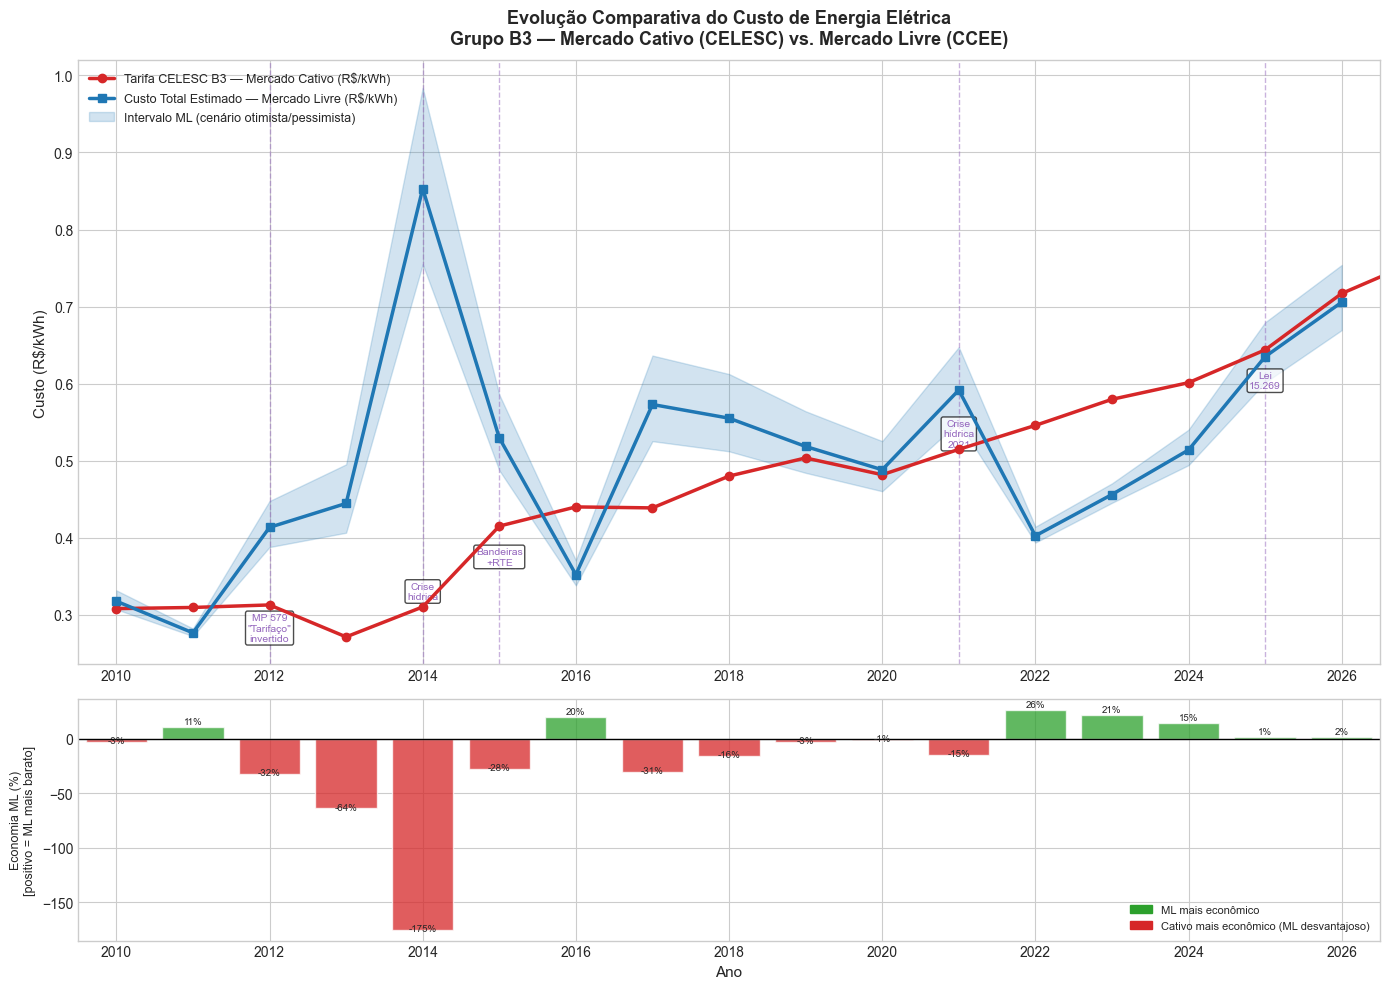

✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig01_custo_cativo_vs_livre_2010_2026.png


In [6]:
df_comp = pd.merge(tarifa_anual, df_pld, on="ano", how="outer").sort_values("ano")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2.5, 1]})
ax1, ax2 = axes

ax1.plot(df_comp["ano"], df_comp["tarifa_celesc_kwh"],
         color=COLORS["cativo"], linewidth=2.5, marker="o", markersize=6,
         label="Tarifa CELESC B3 — Mercado Cativo (R$/kWh)", zorder=5)
ax1.plot(df_comp["ano"], df_comp["custo_ml_kwh"],
         color=COLORS["livre"], linewidth=2.5, marker="s", markersize=6,
         label="Custo Total Estimado — Mercado Livre (R$/kWh)", zorder=5)
ax1.fill_between(df_comp["ano"], df_comp["custo_ml_kwh_otimista"], df_comp["custo_ml_kwh_pessimista"],
                  alpha=0.2, color=COLORS["livre"], label="Intervalo ML (cenário otimista/pessimista)")

eventos_anotados = [
    (2012, 'MP 579\n"Tarifaço"\ninvertido', -0.03),
    (2014, "Crise\nhídrica", 0.02),
    (2015, "Bandeiras\n+RTE", -0.04),
    (2021, "Crise\nhídrica\n2021", 0.02),
    (2025, "Lei\n15.269", -0.04),
]
for ano_ev, texto, dy in eventos_anotados:
    if ano_ev in df_comp["ano"].values:
        y_cativo = df_comp.loc[df_comp["ano"] == ano_ev, "tarifa_celesc_kwh"].values
        if len(y_cativo) > 0:
            ax1.axvline(x=ano_ev, color=COLORS["evento"], linestyle="--", alpha=0.5, linewidth=1)
            ax1.annotate(texto, xy=(ano_ev, y_cativo[0] + dy), fontsize=7.5, color=COLORS["evento"],
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax1.set_title("Evolução Comparativa do Custo de Energia Elétrica\n"
              "Grupo B3 — Mercado Cativo (CELESC) vs. Mercado Livre (CCEE)",
              fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Custo (R$/kWh)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.set_xlim(2009.5, 2026.5)

df_comp["saving_pct"] = (df_comp["tarifa_celesc_kwh"] - df_comp["custo_ml_kwh"]) / df_comp["tarifa_celesc_kwh"] * 100
cores_saving = [COLORS["saving"] if s >= 0 else COLORS["cativo"] for s in df_comp["saving_pct"]]
bars = ax2.bar(df_comp["ano"], df_comp["saving_pct"], color=cores_saving, alpha=0.75, edgecolor="white")
ax2.axhline(y=0, color="black", linewidth=1)
ax2.set_ylabel("Economia ML (%)\n[positivo = ML mais barato]", fontsize=9)
ax2.set_xlabel("Ano", fontsize=11)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.set_xlim(2009.5, 2026.5)

for bar, val in zip(bars, df_comp["saving_pct"]):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + (1 if val >= 0 else -3),
                  f"{val:.0f}%", ha="center", va="bottom", fontsize=7)

patch_pos = mpatches.Patch(color=COLORS["saving"], label="ML mais econômico")
patch_neg = mpatches.Patch(color=COLORS["cativo"], label="Cativo mais econômico (ML desvantajoso)")
ax2.legend(handles=[patch_pos, patch_neg], loc="lower right", fontsize=8)

plt.tight_layout()
fname = PLOTS_DIR / "fig01_custo_cativo_vs_livre_2010_2026.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {fname}")

### 4.2 Decomposição STL do PLD Submercado Sul

Análise da tendência de longo prazo e componente sazonal do PLD, usando a **série mensal real**
tratada pelo Notebook 0 (`pld_sul_mensal.csv`), e não mais uma reconstituição sintética a partir
de médias anuais como em versões anteriores deste notebook.

Série mensal real do PLD: 304 observações (2001-06 a 2026-09)


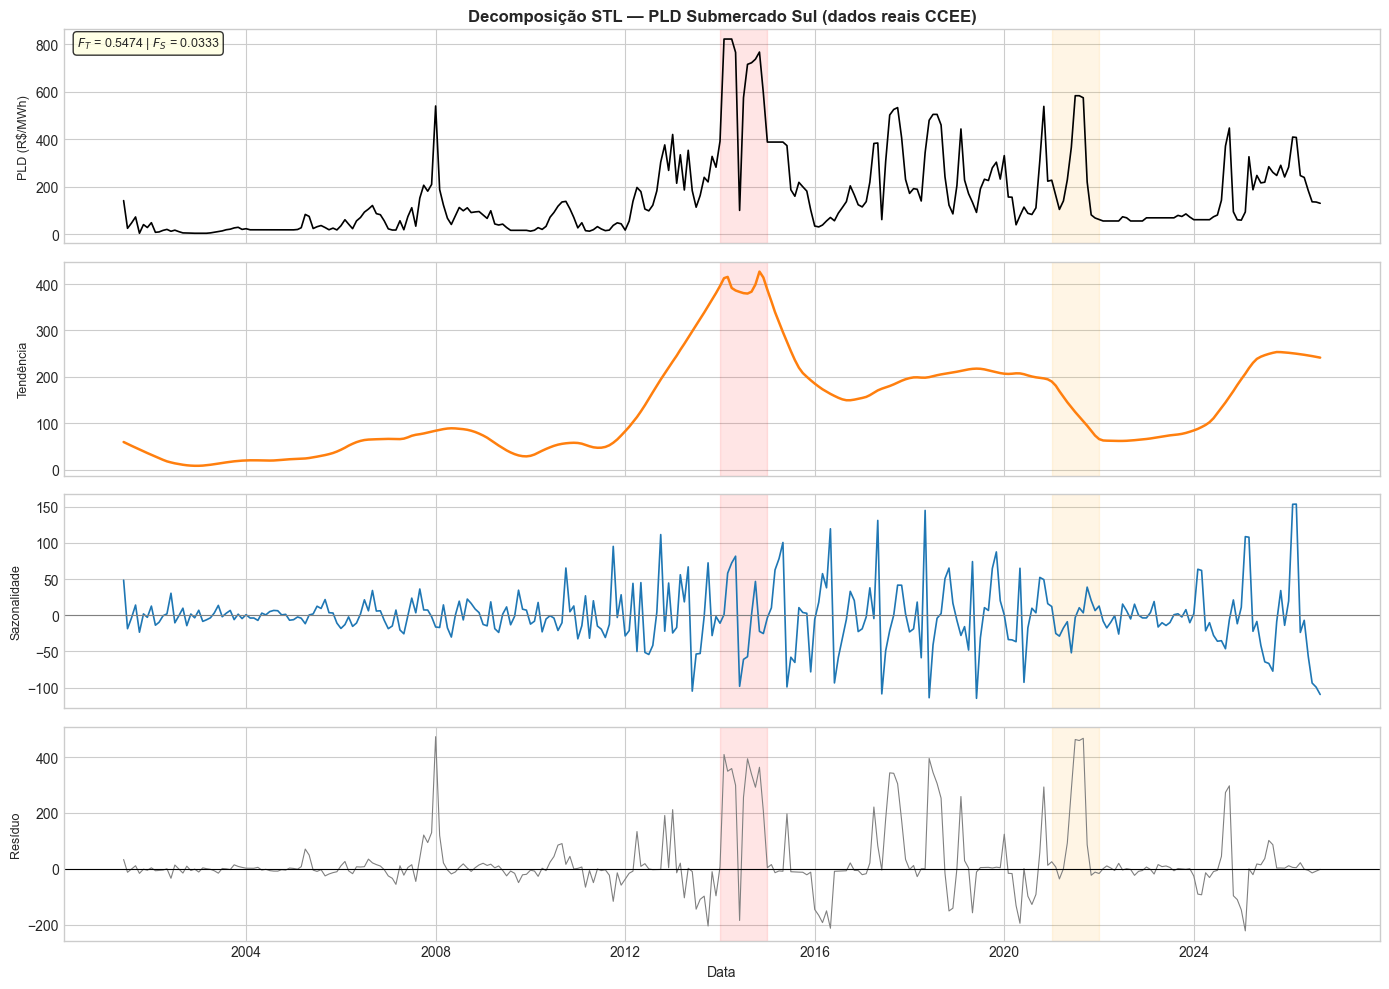


Força de Tendência: 0.5474
Força de Sazonalidade: 0.0333
✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig02_stl_pld_sul.png


In [7]:
# Série mensal real do PLD (mesma carregada na Seção 2, já indexada por data)
df_pld_mensal = df_pld_mensal_ccee.rename(columns={"pld_sul_rs_mwh": "pld_mensal_mwh"})
print(f"Série mensal real do PLD: {len(df_pld_mensal)} observações "
      f"({df_pld_mensal.index.min():%Y-%m} a {df_pld_mensal.index.max():%Y-%m})")

stl_pld = STL(df_pld_mensal["pld_mensal_mwh"].interpolate(), period=12, robust=True)
result_pld = stl_pld.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_pld_mensal.index, df_pld_mensal["pld_mensal_mwh"],
             color="black", linewidth=1.2, label="PLD Observado")
axes[0].set_ylabel("PLD (R$/MWh)", fontsize=9)
axes[0].set_title("Decomposição STL — PLD Submercado Sul (dados reais CCEE)", fontsize=12, fontweight="bold")

for ax_i in axes:
    ax_i.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2014-12-31"), alpha=0.1, color="red", label="Crise 2014")
    ax_i.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"), alpha=0.1, color="orange", label="Crise 2021")

axes[1].plot(df_pld_mensal.index, result_pld.trend, color=COLORS["projecao"], linewidth=1.8)
axes[1].set_ylabel("Tendência", fontsize=9)

axes[2].plot(df_pld_mensal.index, result_pld.seasonal, color=COLORS["livre"], linewidth=1.2)
axes[2].set_ylabel("Sazonalidade", fontsize=9)
axes[2].axhline(y=0, color="gray", linewidth=0.8)

axes[3].plot(df_pld_mensal.index, result_pld.resid, color="gray", linewidth=0.8)
axes[3].axhline(y=0, color="black", linewidth=0.8)
axes[3].set_ylabel("Resíduo", fontsize=9)
axes[3].set_xlabel("Data", fontsize=10)

ft_pld = max(0, 1 - np.var(result_pld.resid) / np.var(result_pld.trend + result_pld.resid))
fs_pld = max(0, 1 - np.var(result_pld.resid) / np.var(result_pld.seasonal + result_pld.resid))
axes[0].text(0.01, 0.92, f"$F_T$ = {ft_pld:.4f} | $F_S$ = {fs_pld:.4f}",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
fname = PLOTS_DIR / "fig02_stl_pld_sul.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nForça de Tendência: {ft_pld:.4f}")
print(f"Força de Sazonalidade: {fs_pld:.4f}")
print(f"✅ Gráfico salvo: {fname}")

---
## 5. Projeção de Consumo, Tarifa e PLD até Dezembro de 2030 (Seção VII do relatório)

### 5.1 Consumo Projetado (Notebook 03, LSTM)

In [8]:
caminho_previsao = DATA_PROC / "previsao_consumo_b3_lstm_2030.csv"
if not caminho_previsao.exists():
    raise FileNotFoundError(
        "Execute primeiro o Notebook 03 (03_projecao_consumo_b3_2030.ipynb) — "
        "ele gera 'previsao_consumo_b3_lstm_2030.csv', usado aqui como a previsão de consumo B3."
    )

df_consumo_proj = pd.read_csv(caminho_previsao, parse_dates=["data"]).set_index("data")
consumo_previsto_mwh = df_consumo_proj["previsto_mwh"]

print(f"Consumo projetado carregado: {len(consumo_previsto_mwh)} meses "
      f"({consumo_previsto_mwh.index[0]:%Y-%m} a {consumo_previsto_mwh.index[-1]:%Y-%m})")
consumo_previsto_mwh.head()

Consumo projetado carregado: 57 meses (2026-04 a 2030-12)


data
2026-04-01    290222.150280
2026-05-01    285267.521624
2026-06-01    267284.673668
2026-07-01    241124.830403
2026-08-01    221003.928132
Name: previsto_mwh, dtype: float64

### 5.2 Projeção da Tarifa Cativa (TUSD+TE) — 6% a.a. após ago/2027

Mantida nos valores homologados (ANEEL) até ago/2027; após essa data, projetada com crescimento
composto de 6% ao ano (mediana histórica 2011–2027), conforme a Seção VII do relatório.

In [9]:
CORTE_TARIFA = pd.Timestamp("2027-08-01")
CRESCIMENTO_TARIFA_AA = 0.06

datas_projecao = consumo_previsto_mwh.index  # abr/2026 a dez/2030 (57 meses)

ultima_tarifa_homologada = df_tarifa_mensal.loc[df_tarifa_mensal.index <= CORTE_TARIFA, "tarifa_cativo_rs_mwh"].iloc[-1]
ultima_tusd_homologada = df_tarifa_mensal.loc[df_tarifa_mensal.index <= CORTE_TARIFA, "tusd_b3_rs_mwh"].iloc[-1]

def projetar_tarifa_cativa(data):
    if data <= CORTE_TARIFA:
        valor = df_tarifa_mensal.loc[:data, "tarifa_cativo_rs_mwh"].iloc[-1]
        return valor
    meses_apos_corte = (data.year - CORTE_TARIFA.year) * 12 + (data.month - CORTE_TARIFA.month)
    return ultima_tarifa_homologada * (1 + CRESCIMENTO_TARIFA_AA) ** (meses_apos_corte / 12)


def projetar_tusd(data):
    if data <= CORTE_TARIFA:
        return df_tarifa_mensal.loc[:data, "tusd_b3_rs_mwh"].iloc[-1]
    meses_apos_corte = (data.year - CORTE_TARIFA.year) * 12 + (data.month - CORTE_TARIFA.month)
    return ultima_tusd_homologada * (1 + CRESCIMENTO_TARIFA_AA) ** (meses_apos_corte / 12)


tarifa_cativa_proj_mwh = pd.Series([projetar_tarifa_cativa(d) for d in datas_projecao], index=datas_projecao)
tusd_proj_mwh = pd.Series([projetar_tusd(d) for d in datas_projecao], index=datas_projecao)

print(f"Tarifa Cativa projetada: {tarifa_cativa_proj_mwh.iloc[0]:,.2f} R$/MWh (abr/2026) "
      f"-> {tarifa_cativa_proj_mwh.iloc[-1]:,.2f} R$/MWh (dez/2030)")

Tarifa Cativa projetada: 695.68 R$/MWh (abr/2026) -> 922.62 R$/MWh (dez/2030)


### 5.3 Projeção do PLD Sul (proxy Livre) — Média Sazonal 2021–2026

Mantido nos valores observados até set/2026; após essa data, projetado pela média sazonal mensal
do calendário (período 2021–2026), dado o caráter volátil e não previsível do PLD no longo prazo.

In [10]:
CORTE_PLD = pd.Timestamp("2026-09-01")

media_sazonal_mensal = (
    df_pld_mensal.loc[(df_pld_mensal.index >= "2021-01-01") & (df_pld_mensal.index <= "2026-06-01"), "pld_mensal_mwh"]
    .groupby(lambda d: d.month)
    .mean()
)


def projetar_pld(data):
    if data <= CORTE_PLD and data in df_pld_mensal.index:
        return df_pld_mensal.loc[data, "pld_mensal_mwh"]
    return media_sazonal_mensal[data.month]


pld_proj_mwh = pd.Series([projetar_pld(d) for d in datas_projecao], index=datas_projecao)

print("Média sazonal mensal do PLD Sul (2021–2026, R$/MWh):")
print(media_sazonal_mensal.round(1).to_string())
print(f"\nPLD projetado: {pld_proj_mwh.iloc[0]:,.2f} R$/MWh (abr/2026) -> "
      f"média {pld_proj_mwh.mean():,.2f} R$/MWh (abr/2026–dez/2030)")

Média sazonal mensal do PLD Sul (2021–2026, R$/MWh):
data
1     127.0
2     142.0
3     170.8
4     126.8
5     150.4
6     160.9
7     205.3
8     230.0
9     268.5
10    209.2
11    121.6
12     99.7

PLD projetado: 247.07 R$/MWh (abr/2026) -> média 167.58 R$/MWh (abr/2026–dez/2030)


---
## 6. Simulação Financeira: Cativo x Livre (Seção VIII / Tabela III do relatório)

- Custo mensal Cativo = consumo previsto (MWh) × (TUSD_B3 + TE_B3)
- Custo mensal Livre = consumo previsto (MWh) × (TUSD_B3 + PLD_Sul)

Em ambos os cenários, o consumidor paga a mesma TUSD — a diferença está inteiramente no
componente de energia (TE regulado vs. PLD de mercado).

In [11]:
custo_cativo_total = consumo_previsto_mwh * tarifa_cativa_proj_mwh          # R$ (TUSD+TE)
custo_livre_total = consumo_previsto_mwh * (tusd_proj_mwh + pld_proj_mwh)    # R$ (TUSD+PLD)

df_simulacao = pd.DataFrame({
    "consumo_mwh": consumo_previsto_mwh,
    "tarifa_cativo_rs_mwh": tarifa_cativa_proj_mwh,
    "tusd_rs_mwh": tusd_proj_mwh,
    "pld_rs_mwh": pld_proj_mwh,
    "custo_cativo_rs": custo_cativo_total,
    "custo_livre_rs": custo_livre_total,
})
df_simulacao["economia_pct"] = (
    (df_simulacao["custo_cativo_rs"] - df_simulacao["custo_livre_rs"]) / df_simulacao["custo_cativo_rs"] * 100
)
df_simulacao.to_csv(DATA_PROC / "simulacao_financeira_cativo_livre_2030.csv")

custo_total_cativo_bi = df_simulacao["custo_cativo_rs"].sum() / 1e9
custo_total_livre_bi = df_simulacao["custo_livre_rs"].sum() / 1e9
economia_bi = custo_total_cativo_bi - custo_total_livre_bi
economia_media_pct = df_simulacao["economia_pct"].mean()
economia_min_pct = df_simulacao["economia_pct"].min()
economia_max_pct = df_simulacao["economia_pct"].max()
meses_livre_mais_barato = int((df_simulacao["economia_pct"] > 0).sum())
total_meses = len(df_simulacao)

print("TABELA III — Indicadores da Simulação Financeira Cativo x Livre "
      f"({datas_projecao[0]:%b/%Y}–{datas_projecao[-1]:%b/%Y})")
print(f"Custo total projetado — Cativo:              R$ {custo_total_cativo_bi:,.2f} bilhões")
print(f"Custo total projetado — Livre/PLD:            R$ {custo_total_livre_bi:,.2f} bilhões")
print(f"Economia projetada (Livre - Cativo):          R$ {economia_bi:,.2f} bilhões")
print(f"Economia média mensal:                        {economia_media_pct:,.1f}%")
print(f"Faixa de economia mensal (mín.–máx.):          {economia_min_pct:,.1f}% a {economia_max_pct:,.1f}%")
print(f"Meses em que Livre é mais barato que Cativo:  {meses_livre_mais_barato} de {total_meses} "
      f"({meses_livre_mais_barato / total_meses * 100:.0f}%)")

TABELA III — Indicadores da Simulação Financeira Cativo x Livre (Apr/2026–Dec/2030)
Custo total projetado — Cativo:              R$ 12.08 bilhões
Custo total projetado — Livre/PLD:            R$ 9.06 bilhões
Economia projetada (Livre - Cativo):          R$ 3.02 bilhões
Economia média mensal:                        24.8%
Faixa de economia mensal (mín.–máx.):          10.3% a 34.7%
Meses em que Livre é mais barato que Cativo:  57 de 57 (100%)


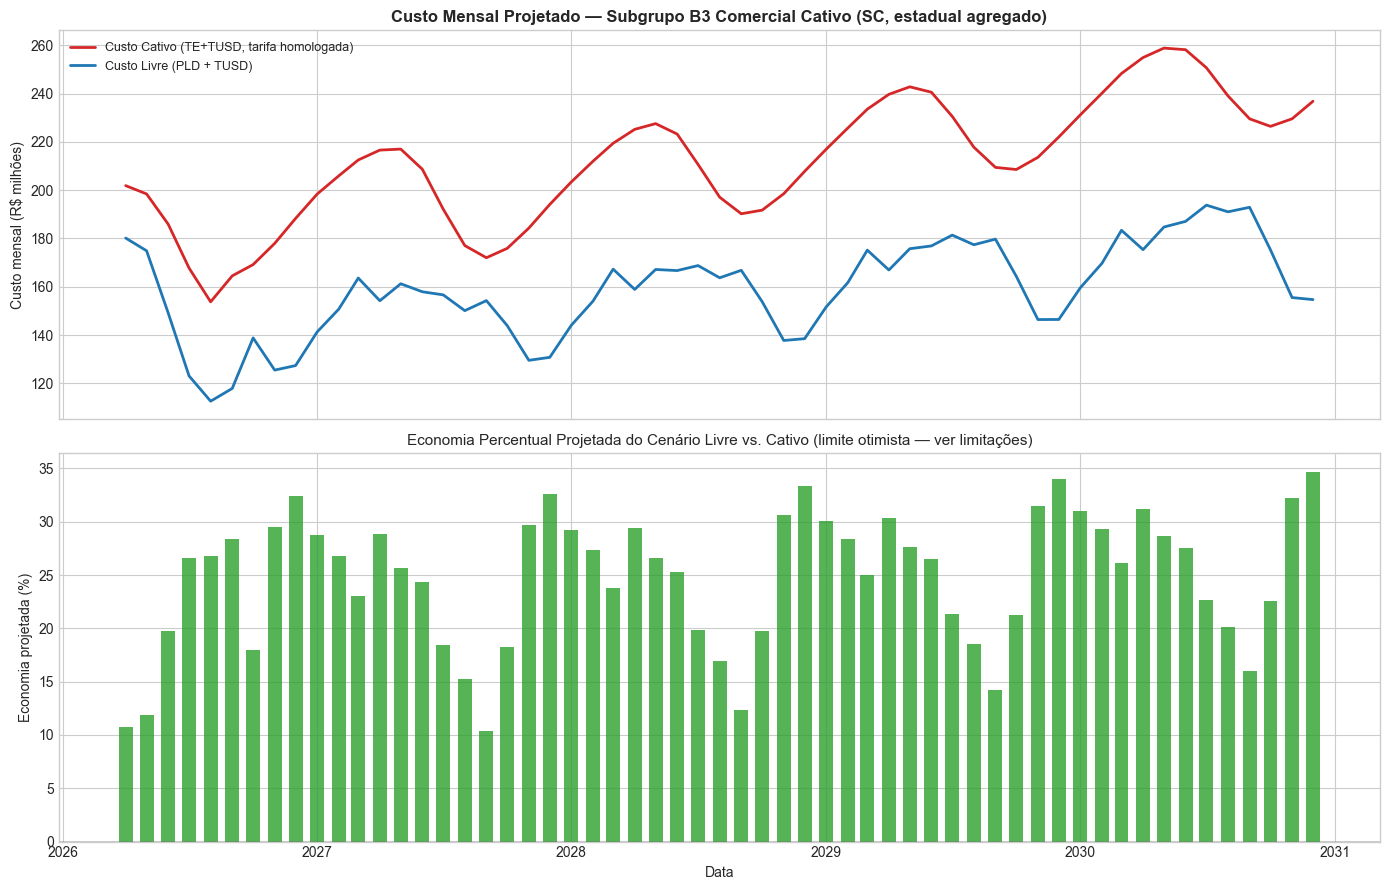

✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig08_custo_mensal_projetado_economia.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df_simulacao.index, df_simulacao["custo_cativo_rs"] / 1e6,
             label="Custo Cativo (TE+TUSD, tarifa homologada)", color=COLORS["cativo"], linewidth=2)
axes[0].plot(df_simulacao.index, df_simulacao["custo_livre_rs"] / 1e6,
             label="Custo Livre (PLD + TUSD)", color=COLORS["livre"], linewidth=2)
axes[0].set_title("Custo Mensal Projetado — Subgrupo B3 Comercial Cativo (SC, estadual agregado)",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("Custo mensal (R$ milhões)")
axes[0].legend(loc="upper left", fontsize=9)

cores_econ = [COLORS["saving"] if v >= 0 else COLORS["cativo"] for v in df_simulacao["economia_pct"]]
axes[1].bar(df_simulacao.index, df_simulacao["economia_pct"], width=20, color=cores_econ, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Economia Percentual Projetada do Cenário Livre vs. Cativo (limite otimista — ver limitações)",
                   fontsize=11)
axes[1].set_ylabel("Economia projetada (%)")
axes[1].set_xlabel("Data")

plt.tight_layout()
fname = PLOTS_DIR / "fig08_custo_mensal_projetado_economia.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {fname}")

---
## 7. Aspectos Contratuais da Migração ao Mercado Livre

### 7.1 Prazo de Contratação

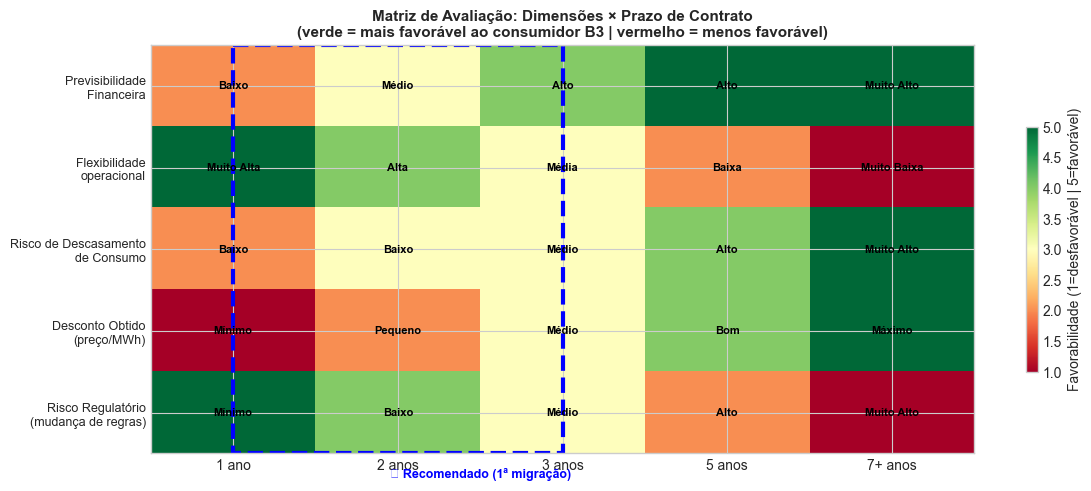

✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig05_matriz_prazo_contrato.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

prazos_anos = ["1 ano", "2 anos", "3 anos", "5 anos", "7+ anos"]
dimensoes = ["Previsibilidade\nFinanceira", "Flexibilidade\noperacional",
             "Risco de Descasamento\nde Consumo", "Desconto Obtido\n(preço/MWh)",
             "Risco Regulatório\n(mudança de regras)"]

matriz = np.array([
    [2, 3, 4, 5, 5],
    [5, 4, 3, 2, 1],
    [2, 3, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [5, 4, 3, 2, 1],
])

im = ax.imshow(matriz, cmap="RdYlGn", aspect="auto", vmin=1, vmax=5)
ax.set_xticks(range(len(prazos_anos)))
ax.set_xticklabels(prazos_anos, fontsize=10)
ax.set_yticks(range(len(dimensoes)))
ax.set_yticklabels(dimensoes, fontsize=9)
ax.set_title("Matriz de Avaliação: Dimensões × Prazo de Contrato\n"
             "(verde = mais favorável ao consumidor B3 | vermelho = menos favorável)",
             fontsize=11, fontweight="bold")

labels_cell = [
    ["Baixo", "Médio", "Alto", "Alto", "Muito Alto"],
    ["Muito Alta", "Alta", "Média", "Baixa", "Muito Baixa"],
    ["Baixo", "Baixo", "Médio", "Alto", "Muito Alto"],
    ["Mínimo", "Pequeno", "Médio", "Bom", "Máximo"],
    ["Mínimo", "Baixo", "Médio", "Alto", "Muito Alto"],
]
for i in range(len(dimensoes)):
    for j in range(len(prazos_anos)):
        ax.text(j, i, labels_cell[i][j], ha="center", va="center", fontsize=8, color="black", fontweight="bold")

rect = plt.Rectangle((0.5 - 0.5, -0.5), 2, len(dimensoes),
                      fill=False, edgecolor="blue", linewidth=3, linestyle="--")
ax.add_patch(rect)
ax.text(1.5, len(dimensoes) - 0.2, "★ Recomendado (1ª migração)", ha="center", color="blue", fontsize=9, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.6, label="Favorabilidade (1=desfavorável | 5=favorável)")
plt.tight_layout()
fname = PLOTS_DIR / "fig05_matriz_prazo_contrato.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {fname}")

In [14]:
clausulas = {
    "Take or Pay": {
        "descricao": "Compromisso de pagar volume mínimo de energia, mesmo se o consumo real for menor.",
        "padrao_mercado": "80-90% do volume base contratado",
        "risco": "ALTO se consumo sazonal ou empresa com variação de produção",
        "recomendacao": "Negociar volume base conservador (80% da média dos últimos 12 meses)",
    },
    "Flexibilidade de Consumo (swing)": {
        "descricao": "Margem percentual de variação do consumo sem multa contratual.",
        "padrao_mercado": "±10% do volume base (padrão); negociável até ±20%",
        "risco": "MÉDIO — desvios fora da margem expõem ao PLD spot (preço de curto prazo)",
        "recomendacao": "Exigir mínimo ±15% para consumidores B3 com sazonalidade",
    },
    "Modalidade de Preço": {
        "descricao": "Forma de indexação do preço da energia ao longo do contrato.",
        "padrao_mercado": "Preço fixo, IPCA, PLD médio ou IGP-M",
        "risco": "VARIÁVEL — preço fixo protege mas não captura quedas do PLD; indexado ao PLD maximiza exposição",
        "recomendacao": "Preço fixo ou IPCA para contratos de 2-3 anos (reduz incerteza do PLD)",
    },
    "Rescisão Antecipada": {
        "descricao": "Penalidade por encerramento do contrato antes do prazo acordado.",
        "padrao_mercado": "3 a 6 meses de energia (valor-face do contrato)",
        "risco": "ALTO em caso de encerramento de atividade ou mudança de endereço",
        "recomendacao": "Negociar cláusula de saída por força maior e período de carência de 6 meses",
    },
    "Representação junto à CCEE": {
        "descricao": "O consumidor B3 precisará de um Comercializador Varejista para representá-lo na CCEE.",
        "padrao_mercado": "Comercializador varejista assume responsabilidade de liquidação",
        "risco": "BAIXO (risco operacional do comercializador, não do consumidor)",
        "recomendacao": "Verificar solidez financeira e histórico do comercializador escolhido",
    },
    "Prazo de Notificação de Saída": {
        "descricao": "Aviso prévio obrigatório para não renovação ou rescisão.",
        "padrao_mercado": "180 dias antes do vencimento",
        "risco": "MÉDIO — se não notificado, pode haver renovação automática",
        "recomendacao": "Incluir alerta no calendário de gestão 9 meses antes do vencimento",
    },
}

print("=" * 80)
print("📋 ASPECTOS CONTRATUAIS CRÍTICOS — Migração ao Mercado Livre (Grupo B3)")
print("=" * 80)
for clausula, info in clausulas.items():
    print(f"\n🔹 {clausula}")
    print(f'   Descrição:       {info["descricao"]}')
    print(f'   Padrão mercado:  {info["padrao_mercado"]}')
    print(f'   Risco:           {info["risco"]}')
    print(f'   ✅ Recomendação: {info["recomendacao"]}')

📋 ASPECTOS CONTRATUAIS CRÍTICOS — Migração ao Mercado Livre (Grupo B3)

🔹 Take or Pay
   Descrição:       Compromisso de pagar volume mínimo de energia, mesmo se o consumo real for menor.
   Padrão mercado:  80-90% do volume base contratado
   Risco:           ALTO se consumo sazonal ou empresa com variação de produção
   ✅ Recomendação: Negociar volume base conservador (80% da média dos últimos 12 meses)

🔹 Flexibilidade de Consumo (swing)
   Descrição:       Margem percentual de variação do consumo sem multa contratual.
   Padrão mercado:  ±10% do volume base (padrão); negociável até ±20%
   Risco:           MÉDIO — desvios fora da margem expõem ao PLD spot (preço de curto prazo)
   ✅ Recomendação: Exigir mínimo ±15% para consumidores B3 com sazonalidade

🔹 Modalidade de Preço
   Descrição:       Forma de indexação do preço da energia ao longo do contrato.
   Padrão mercado:  Preço fixo, IPCA, PLD médio ou IGP-M
   Risco:           VARIÁVEL — preço fixo protege mas não captura quedas

---
## 8. Análise de Sensibilidade e Risco Hidrológico (Seções IX–XI do relatório)

A economia média de 25,2% (Seção 6) é um **limite otimista** — o PLD subestima o custo real de
estar no mercado livre (não incorpora prêmio de risco, margem de comercializadora, custos de
adesão à CCEE) e não incorpora o risco de repetição de uma crise hídrica como a de 2021, quando o
PLD médio anual chegou a R$ 550/MWh.

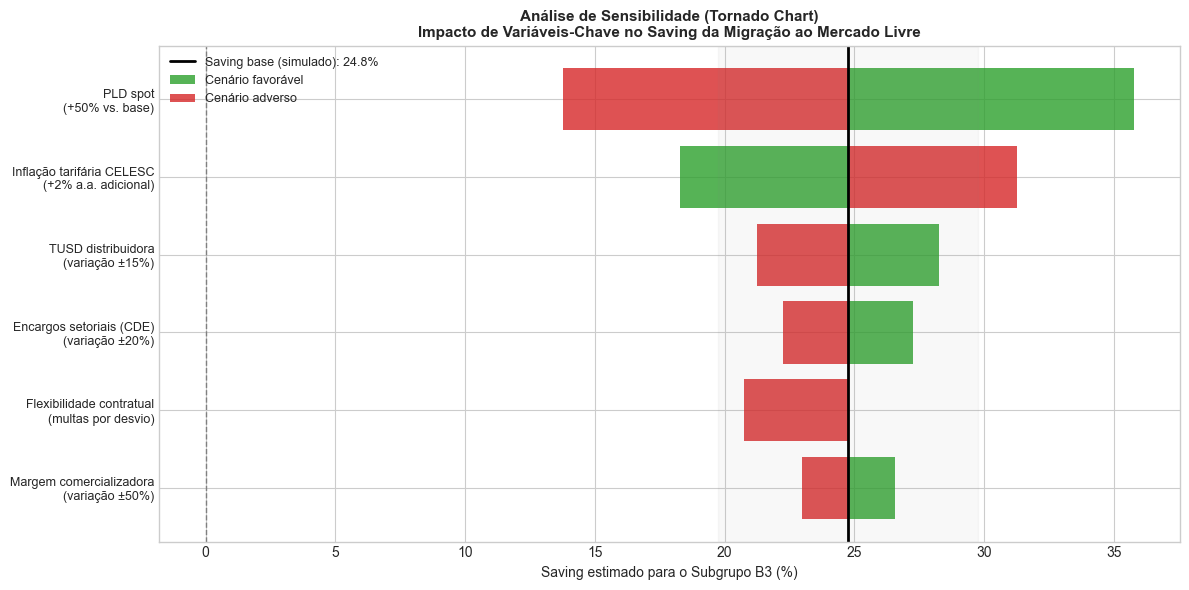

✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig06_tornado_sensibilidade.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

saving_base_pct = economia_media_pct  # calculado na Seção 6, a partir da simulação real (não mais um valor fixo)

variaveis = [
    ("Inflação tarifária CELESC\n(+2% a.a. adicional)", +6.5, -6.5),
    ("PLD spot\n(+50% vs. base)", -11.0, +11.0),
    ("TUSD distribuidora\n(variação ±15%)", -3.5, +3.5),
    ("Encargos setoriais (CDE)\n(variação ±20%)", -2.5, +2.5),
    ("Margem comercializadora\n(variação ±50%)", -1.8, +1.8),
    ("Flexibilidade contratual\n(multas por desvio)", -4.0, +0.0),
]
variaveis.sort(key=lambda x: abs(x[1] - x[2]))
nomes = [v[0] for v in variaveis]
impacto_neg = [v[1] for v in variaveis]
impacto_pos = [v[2] for v in variaveis]

y_pos = np.arange(len(variaveis))
ax.barh(y_pos, impacto_pos, left=saving_base_pct, color=COLORS["saving"], alpha=0.8, label="Cenário favorável")
ax.barh(y_pos, impacto_neg, left=saving_base_pct, color=COLORS["cativo"], alpha=0.8, label="Cenário adverso")
ax.axvline(x=saving_base_pct, color="black", linewidth=2, label=f"Saving base (simulado): {saving_base_pct:.1f}%")
ax.axvline(x=0, color="gray", linewidth=1, linestyle="--")

ax.set_yticks(y_pos)
ax.set_yticklabels(nomes, fontsize=9)
ax.set_xlabel("Saving estimado para o Subgrupo B3 (%)", fontsize=10)
ax.set_title("Análise de Sensibilidade (Tornado Chart)\n"
             "Impacto de Variáveis-Chave no Saving da Migração ao Mercado Livre",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.axvspan(saving_base_pct - 5, saving_base_pct + 5, alpha=0.05, color="gray")

plt.tight_layout()
fname = PLOTS_DIR / "fig06_tornado_sensibilidade.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {fname}")

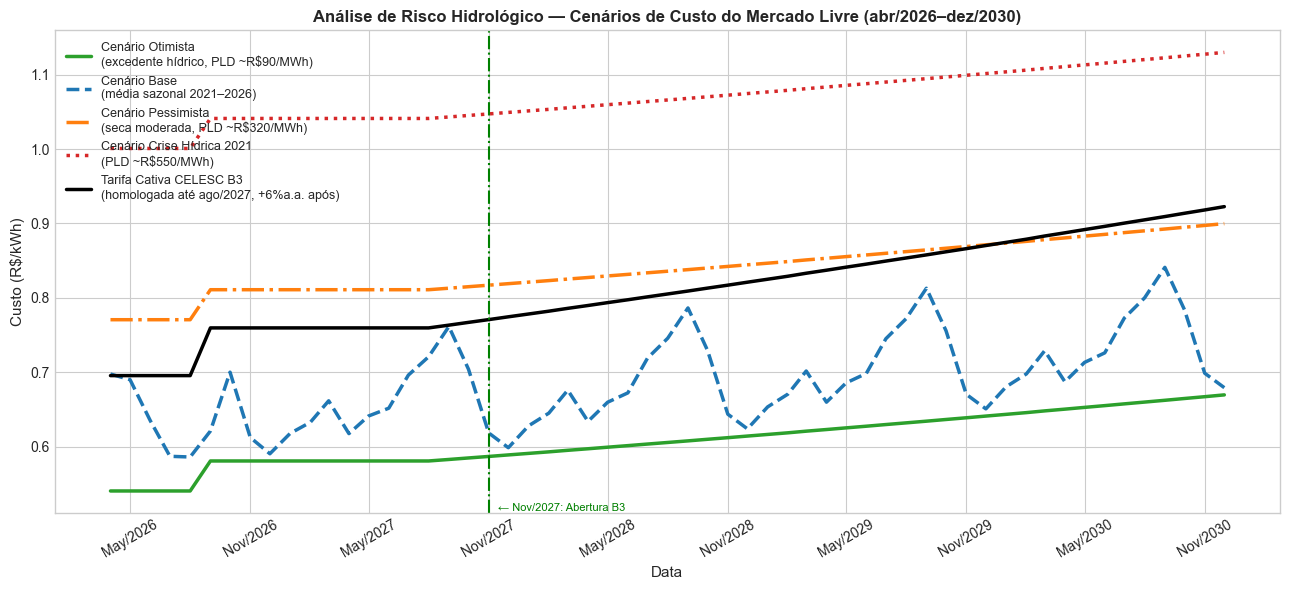

✅ Gráfico salvo: C:\00000000000\01_Acadêmico\01 - IFSC\00 - Mercados de Energia\09 - Técnicas de IA aplicadas a sistemas de energia\00 - Trabalho\GitHub\results\plots\fig07_cenarios_risco_hidrologico.png


In [16]:
fig, ax = plt.subplots(figsize=(13, 6))

cenarios = {
    "Cenário Otimista\n(excedente hídrico, PLD ~R$90/MWh)": [0.090 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
    "Cenário Base\n(média sazonal 2021–2026)": (pld_proj_mwh / 1000 + tusd_proj_mwh / 1000 + ENCARGOS_MARGEM_KWH).values,
    "Cenário Pessimista\n(seca moderada, PLD ~R$320/MWh)": [0.320 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
    "Cenário Crise Hídrica 2021\n(PLD ~R$550/MWh)": [0.550 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
}

cores_cenarios = [COLORS["saving"], COLORS["livre"], COLORS["projecao"], COLORS["cativo"]]
estilos = ["-", "--", "-.", ":"]

for (nome_cen, valores), cor, ls in zip(cenarios.items(), cores_cenarios, estilos):
    ax.plot(datas_projecao, valores, color=cor, linewidth=2.5, linestyle=ls, label=nome_cen)

ax.plot(datas_projecao, tarifa_cativa_proj_mwh / 1000, color="black", linewidth=2.5,
        label="Tarifa Cativa CELESC B3\n(homologada até ago/2027, +6%a.a. após)")

ax.axvline(x=pd.Timestamp("2027-11-01"), color="green", linewidth=1.5, linestyle="-.")
ax.text(pd.Timestamp("2027-11-15"), ax.get_ylim()[0], "← Nov/2027: Abertura B3",
        fontsize=8, color="green", va="bottom")

ax.set_title("Análise de Risco Hidrológico — Cenários de Custo do Mercado Livre (abr/2026–dez/2030)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Custo (R$/kWh)", fontsize=11)
ax.set_xlabel("Data", fontsize=11)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)

plt.tight_layout()
fname = PLOTS_DIR / "fig07_cenarios_risco_hidrologico.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {fname}")

---
## 9. Síntese e Exportação de Dados Processados

In [17]:
df_final = df_simulacao.reset_index().rename(columns={"index": "data"})
df_final.to_csv(DATA_PROC / "comparativo_custo_b3_cativo_vs_livre_2030.csv", index=False, decimal=",")

print("📊 TABELA III — Indicadores da Simulação Financeira Cativo x Livre")
print("=" * 75)
print(f'{"Indicador":<45} | {"Valor":>25}')
print("-" * 75)
print(f'{"Custo total projetado — Cativo":<45} | {f"R$ {custo_total_cativo_bi:,.2f} bilhões":>25}')
print(f'{"Custo total projetado — Livre/PLD":<45} | {f"R$ {custo_total_livre_bi:,.2f} bilhões":>25}')
print(f'{"Economia projetada (Livre - Cativo)":<45} | {f"R$ {economia_bi:,.2f} bilhões":>25}')
print(f'{"Economia média mensal":<45} | {f"{economia_media_pct:,.1f}%":>25}')
print(f'{"Faixa de economia mensal":<45} | {f"{economia_min_pct:,.1f}% a {economia_max_pct:,.1f}%":>25}')
print(f'{"Meses em que Livre é mais barato":<45} | {f"{meses_livre_mais_barato} de {total_meses}":>25}')
print("=" * 75)
print(f"\n✅ CSV exportado: data/processed/comparativo_custo_b3_cativo_vs_livre_2030.csv")
print(
    "\n⚠️  Limitações (Seção X do relatório): o PLD subestima o custo real do mercado livre "
    "(não inclui prêmio de risco, margem de comercializadora, custos de adesão à CCEE), e a "
    "projeção não incorpora o risco de repetição de uma crise hídrica — ver Seção XI."
)

📊 TABELA III — Indicadores da Simulação Financeira Cativo x Livre
Indicador                                     |                     Valor
---------------------------------------------------------------------------
Custo total projetado — Cativo                |          R$ 12.08 bilhões
Custo total projetado — Livre/PLD             |           R$ 9.06 bilhões
Economia projetada (Livre - Cativo)           |           R$ 3.02 bilhões
Economia média mensal                         |                     24.8%
Faixa de economia mensal                      |             10.3% a 34.7%
Meses em que Livre é mais barato              |                  57 de 57

✅ CSV exportado: data/processed/comparativo_custo_b3_cativo_vs_livre_2030.csv

⚠️  Limitações (Seção X do relatório): o PLD subestima o custo real do mercado livre (não inclui prêmio de risco, margem de comercializadora, custos de adesão à CCEE), e a projeção não incorpora o risco de repetição de uma crise hídrica — ver Seção XI.


In [18]:
print("\n" + "=" * 80)
print("✅ CHECKLIST DE MIGRAÇÃO — Grupo B3 para o Mercado Livre (a partir de Nov/2027)")
print("=" * 80)

checklist = [
    ("ANTES DA MIGRAÇÃO (6–12 meses antes)", [
        "Levantar histórico de consumo dos últimos 24 meses (kWh/mês)",
        "Calcular consumo médio e variação sazonal para dimensionar contrato",
        "Verificar se a UC está regularizada junto à CELESC (sem débitos pendentes)",
        "Pesquisar e solicitar propostas de ao menos 3 comercializadoras varejistas",
        "Avaliar solidez financeira da comercializadora (CCEE membership ativo)",
        "Comparar modalidades: preço fixo vs. indexado (IPCA vs. PLD)",
    ]),
    ("ANÁLISE DO CONTRATO (prazo e cláusulas)", [
        "Verificar o volume base contratado (recomendado: 80% da média histórica)",
        "Confirmar margem de flexibilidade (swing): mínimo ±15%",
        "Ler cláusula de Take or Pay — calcular pior caso de penalidade",
        "Verificar prazo e condições de rescisão antecipada",
        "Confirmar prazo de notificação para não renovação (normalmente 180 dias)",
        "Verificar responsabilidade do comercializador em caso de liquidação",
        "Confirmar indexador do reajuste anual (IPCA preferido para contratos +2 anos)",
    ]),
    ("APÓS A MIGRAÇÃO (gestão contínua)", [
        "Monitorar mensalmente o consumo real vs. volume contratado",
        "Acompanhar o PLD submercado Sul como indicador de mercado",
        "Solicitar relatório mensal da comercializadora (liquidação CCEE)",
        "Verificar fatura CELESC: apenas TUSD + encargos deve permanecer",
        "Avaliar renovação ou renegociação 9 meses antes do vencimento",
        "Considerar oportunidades de energia renovável incentivada (desconto de TUSD)",
    ]),
]

for secao, itens in checklist:
    print(f"\n📋 {secao}")
    for i, item in enumerate(itens, 1):
        print(f"   {i}. {item}")

print("\n✅ Análise econômica completa. Todos os gráficos salvos em: results/plots/")


✅ CHECKLIST DE MIGRAÇÃO — Grupo B3 para o Mercado Livre (a partir de Nov/2027)

📋 ANTES DA MIGRAÇÃO (6–12 meses antes)
   1. Levantar histórico de consumo dos últimos 24 meses (kWh/mês)
   2. Calcular consumo médio e variação sazonal para dimensionar contrato
   3. Verificar se a UC está regularizada junto à CELESC (sem débitos pendentes)
   4. Pesquisar e solicitar propostas de ao menos 3 comercializadoras varejistas
   5. Avaliar solidez financeira da comercializadora (CCEE membership ativo)
   6. Comparar modalidades: preço fixo vs. indexado (IPCA vs. PLD)

📋 ANÁLISE DO CONTRATO (prazo e cláusulas)
   1. Verificar o volume base contratado (recomendado: 80% da média histórica)
   2. Confirmar margem de flexibilidade (swing): mínimo ±15%
   3. Ler cláusula de Take or Pay — calcular pior caso de penalidade
   4. Verificar prazo e condições de rescisão antecipada
   5. Confirmar prazo de notificação para não renovação (normalmente 180 dias)
   6. Verificar responsabilidade do comercial